# **Telco Customer Churn Prediction**
*Predicting customer churn using classification models (Logistic Regression, Decision Tree, Random Forest) on the Telco Customer Churn dataset.*

In [1]:
!pip install kaggle
!kaggle datasets download -d blastchar/telco-customer-churn

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
telco-customer-churn.zip: Skipping, found more recently modified local copy (use --force to force download)


In [2]:
import pandas as pd
df = pd.read_csv('telco-customer-churn.zip')

In [3]:
df.shape

(7043, 21)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info() # What's the data type of columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Any missing values ?
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# How does the data look mathemmatically 
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
# Are there duplicates values
df.duplicated().sum()

np.int64(0)

# `Pandas Profiling`

In [9]:
!pip install ydata-profiling

In [10]:
from ydata_profiling import ProfileReport
prof=ProfileReport(df)
prof.to_file(output_file='output1.html')

C:\Users\shagun\AppData\Local\Temp\ipykernel_8520\2376525938.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 21/21 [00:01<00:00, 18.88it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [11]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

# **Data cleaning**

In [12]:
import sklearn
from sklearn.preprocessing import OrdinalEncoder

In [13]:
cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
oe = OrdinalEncoder(categories=[['No', 'Yes']] * len(cols))   #categories must be a list of lists
df[cols] = oe.fit_transform(df[cols])

In [14]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1.0,0.0,1,0.0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1.0,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0.0,0.0,34,1.0,No,DSL,Yes,...,Yes,No,No,No,One year,0.0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,0.0,0.0,2,1.0,No,DSL,Yes,...,No,No,No,No,Month-to-month,1.0,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0.0,0.0,45,0.0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0.0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0.0,0.0,2,1.0,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1.0,Electronic check,70.70,151.65,1


In [16]:
# Drop customerID bcoz it is uniques doesn't give any signal about churn or not churn
df = df.drop(columns=['customerID'])

In [17]:
df['TotalCharges'].dtype

dtype('O')

In [18]:
# The errors='coerce' part tells pandas: "wherever you can't convert something to a number, just put NaN instead of crashing."
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].dtype

dtype('float64')

In [19]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [20]:
#Since that's a tiny fraction of ~7000 rows, just drop them:
df.dropna(inplace=True)   #Iterate over row by row if it get any null value for any col it drop that row

In [21]:
# One-hot-encoder
# 3+ categories with no natural order (Contract type, Payment method, Internet service) → one-hot encoding
# 3+ categories with a natural order (like "Low/Medium/High") → label encoding is actually fine there, since the order is real
df = pd.get_dummies(df, columns=[ 'gender','Contract','MultipleLines', 'InternetService', 'PaymentMethod', 
                                   'OnlineSecurity', 'TechSupport', 'OnlineBackup', 
                                   'DeviceProtection', 'StreamingTV', 'StreamingMovies', 
                                   ], drop_first=True)

In [22]:
df.shape

(7032, 31)

In [23]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_No internet service,TechSupport_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,1.0,0.0,1,0.0,1.0,29.85,29.85,0,False,...,False,False,False,True,False,False,False,False,False,False
1,0,0.0,0.0,34,1.0,0.0,56.95,1889.50,0,True,...,False,False,False,False,False,True,False,False,False,False
2,0,0.0,0.0,2,1.0,1.0,53.85,108.15,1,True,...,False,False,False,True,False,False,False,False,False,False
3,0,0.0,0.0,45,0.0,0.0,42.30,1840.75,0,True,...,False,True,False,False,False,True,False,False,False,False
4,0,0.0,0.0,2,1.0,1.0,70.70,151.65,1,False,...,False,False,False,False,False,False,False,False,False,False


In [24]:
df = df.astype(int) # Only if u want all columns in int type 

# if u don't have int type in all columns then use
# bool_cols = df.select_dtypes(include='bool').columns
# df[bool_cols] = df[bool_cols].astype(int)

In [25]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_No internet service,TechSupport_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,1,0,1,0,1,29,29,0,0,...,0,0,0,1,0,0,0,0,0,0
1,0,0,0,34,1,0,56,1889,0,1,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0,2,1,1,53,108,1,1,...,0,0,0,1,0,0,0,0,0,0
3,0,0,0,45,0,0,42,1840,0,1,...,0,1,0,0,0,1,0,0,0,0
4,0,0,0,2,1,1,70,151,1,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
df['Churn'].value_counts(normalize=True)   # overall churn rate
df.groupby('tenure')['Churn'].mean()        # does churn rate change with tenure?

tenure
1     0.619902
2     0.516807
3     0.470000
4     0.471591
5     0.481203
        ...   
68    0.090000
69    0.084211
70    0.092437
71    0.035294
72    0.016575
Name: Churn, Length: 72, dtype: float64

In [27]:
# From above data we get clear insight
# Tenure 1 month: ~62% churn
# Tenure 68-72 months: ~2-9% churn
# new customers churn a lot, long-term customers barely churn at all.

In [28]:
df.corr()['Churn'].sort_values(ascending=False)

Churn                                    1.000000
InternetService_Fiber optic              0.307463
PaymentMethod_Electronic check           0.301455
MonthlyCharges                           0.192922
PaperlessBilling                         0.191454
SeniorCitizen                            0.150541
StreamingTV_Yes                          0.063254
StreamingMovies_Yes                      0.060860
MultipleLines_Yes                        0.040033
PhoneService                             0.011691
gender_Male                             -0.008545
MultipleLines_No phone service          -0.011691
DeviceProtection_Yes                    -0.066193
OnlineBackup_Yes                        -0.082307
PaymentMethod_Mailed check              -0.090773
PaymentMethod_Credit card (automatic)   -0.134687
Partner                                 -0.149982
Dependents                              -0.163128
TechSupport_Yes                         -0.164716
OnlineSecurity_Yes                      -0.171270


In [29]:
# tenure (-0.35) → confirms mine earlier finding: longer tenure = less churn
# Contract_Two year (-0.30) → 2-year contracts strongly reduce churn
# InternetService_Fiber optic (+0.31) → fiber customers churn more (maybe pricing or service issues)
# PaymentMethod_Electronic check (+0.30) → customers paying by electronic check churn more
# TotalCharges (-0.20), MonthlyCharges (+0.19) → makes sense: cheaper/newer customers churn more easily

# **VISULAIZATION**

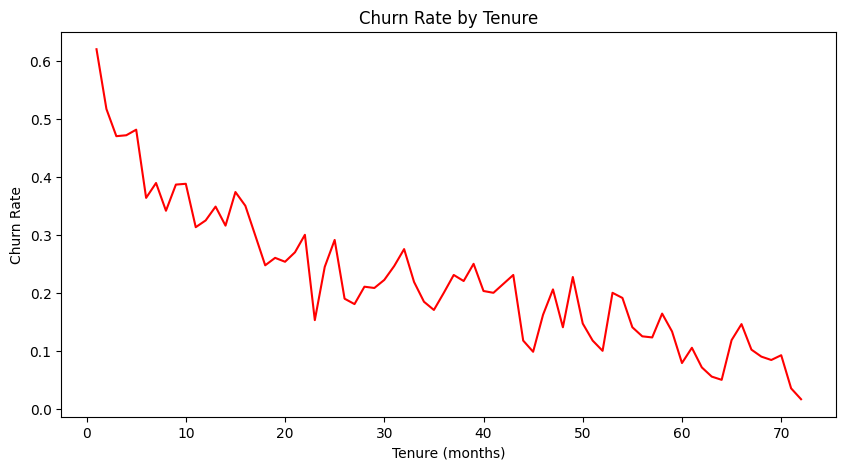

In [30]:
#  Churn rate by tenure
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.lineplot(data=df.groupby('tenure')['Churn'].mean().reset_index(), x='tenure', y='Churn',color='red')
plt.title('Churn Rate by Tenure')
plt.xlabel('Tenure (months)')
plt.ylabel('Churn Rate')
plt.show()

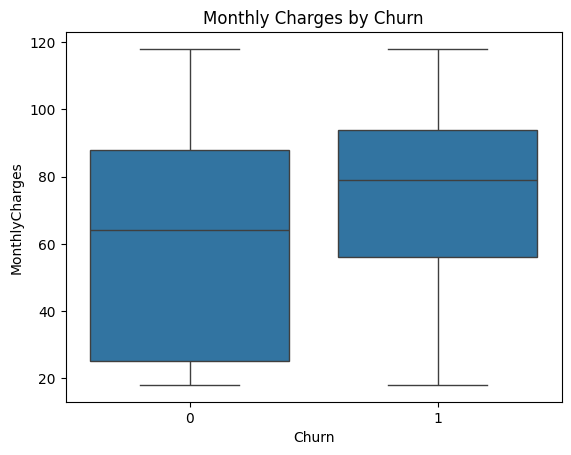

In [31]:
#  Monthly charges vs churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges by Churn')
plt.show()

In [32]:
# One extra thing ican now say that correlation alone didn't tell you:
# The spread for churned customers is narrower — meaning people who churn tend to cluster 
#in the $55-95 range, whereas people who stay are spread more widely from $25-90. 
#This kind of detail (spread, not just average) is something a correlation number can't show you — 
#only the plot reveals it. 

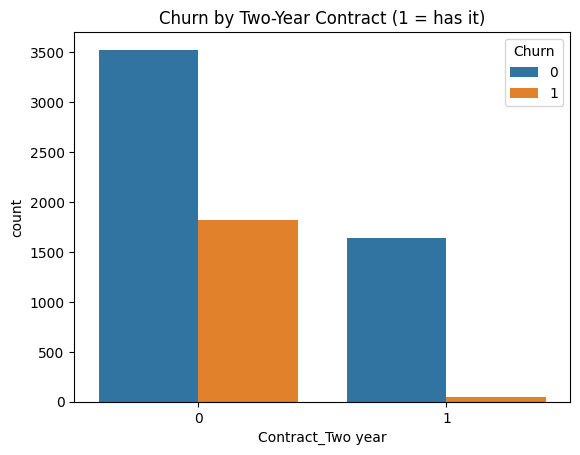

In [33]:
# Contract type vs churn
sns.countplot(data=df, x='Contract_Two year', hue='Churn')
plt.title('Churn by Two-Year Contract (1 = has it)')
plt.show()
# As we notice from correlation two yr contract strongly reduce churn 
#"Customers on two-year contracts almost never churn, 
#while customers without long-term contracts churn at a much higher rate —
#contract length appears to be one of the strongest retention factors."

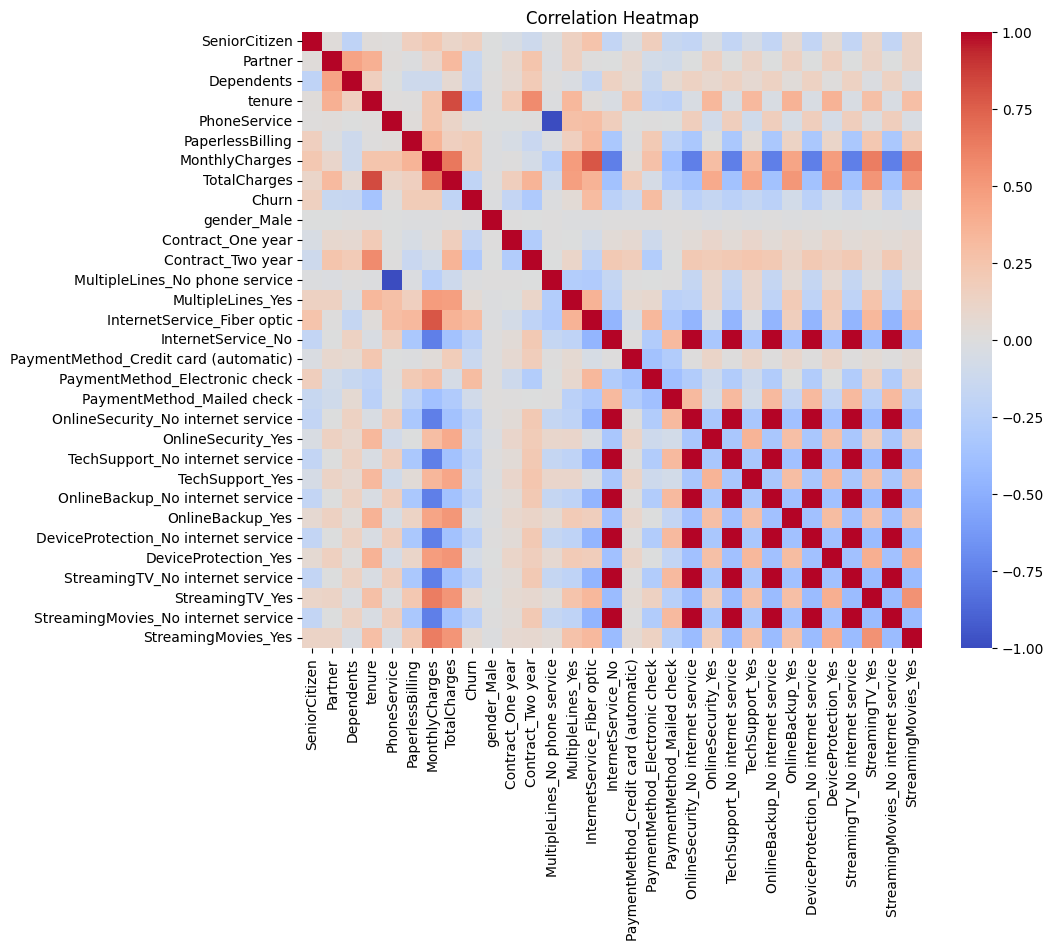

In [34]:
# Correlation heatmap

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

#No single feature has an extremely strong individual correlation with churn

# **DATA MODELING**

In [35]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_No internet service,TechSupport_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,1,0,1,0,1,29,29,0,0,...,0,0,0,1,0,0,0,0,0,0
1,0,0,0,34,1,0,56,1889,0,1,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0,2,1,1,53,108,1,1,...,0,0,0,1,0,0,0,0,0,0
3,0,0,0,45,0,0,42,1840,0,1,...,0,1,0,0,0,1,0,0,0,0
4,0,0,0,2,1,1,70,151,1,0,...,0,0,0,0,0,0,0,0,0,0


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

X = df.drop(['Churn'], axis=1)
# X = pd.concat([df.iloc[:, 0:8], df.iloc[:, 9:31]], axis=1)
Y=df["Churn"]

In [37]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size=0.1)
feature_names = X_train.columns.tolist()
# Scaling data
# why so that it fit the scaler to the train set example --> monthly charges and total charges dono ko scaled kerke same range mei lana basically (day_24)

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train0 = sc.fit_transform(X_train)
X_test0 = sc.transform(X_test)

# **`Logistic Regression`**

In [38]:
# model train
from sklearn.linear_model import LogisticRegression
model0 = LogisticRegression(class_weight='balanced',random_state=42)
model0.fit(X_train0 , Y_train)
Y_pred0 = model0.predict(X_test0)

#accuracy score
from sklearn.metrics import accuracy_score
acc = accuracy_score(Y_test , Y_pred0)
print("Accuracy from logistic regression: ",acc)

Accuracy from logistic regression:  0.734375


In [39]:
# Confusion matrix
# it tells u abt how much your data predict wrong
# prediction(1,0)(horizontal)
# Actual(1,0)(vertical)
from sklearn.metrics import confusion_matrix
confusion_matrix(Y_test,Y_pred0)

#output means-
# positive-1
# negative-0
# 365-pred-churn and actual-churn [true positive]
# 28 - pred - not churn but in actual it's churn [False negative]
# 155 - predicted churn but in actual it's not churn [False positive]
# 156 - both pred and actual not churn [true negative]

# we can calculate accuracy from confusion matrix but reverse is not true
# Type 1 error - False negative
# Type 2 error - False positive

# Note- What's the best accuracy ?
# Best accuracy depends upon the dataset

# Accuracy score is not good for imbalanced dataset !!
# confusion matrix can mislead u 
# Imbalanced dataset means yea or no in the ratio of 9:1 means not in the equal ratio
# So to overcome this problem we use precision,recall and F1 score


array([[389, 142],
       [ 45, 128]])

In [40]:
# Precision(P) = TP/(TP+FP)
# Recall(R) = TP/(TP+FN)

#F1 Score = 2P*R/(P+R) [harmonic mean]
# F1 score always stay on lower value side

from sklearn.metrics import recall_score, precision_score, f1_score

print('For logistic regression')
print("-"*50)
cdf = pd.DataFrame(confusion_matrix(Y_test,Y_pred0))
print(cdf)
print("-"*50)

print('Precision-', precision_score(Y_test,Y_pred0))
print('Recall-', recall_score(Y_test,Y_pred0))
print('F1 Score-', f1_score(Y_test,Y_pred0))


For logistic regression
--------------------------------------------------
     0    1
0  389  142
1   45  128
--------------------------------------------------
Precision- 0.4740740740740741
Recall- 0.7398843930635838
F1 Score- 0.5778781038374717


In [41]:
# Why precision score is different from accuracy score --- because it's imbalanced data, accuracy can be misleading

# Precision — of everyone I predicted as churn, how many actually churned
# Recall — of everyone who actually churned, how many I correctly caught

# Missing a churner (false negative) is usually worse than a false alarm (false positive)
# So: try to make recall value better (more important than precision for churn)
# Next: try a different model (Decision tree & Random Forest) to see if recall improves

## **Which metric matters - Accuracy, Precision, Recall, or F1?**

There's no single universal answer - it depends on the problem and what each type of mistake costs you.

- **Accuracy** matters when your classes are roughly balanced AND both types of mistakes cost about the same. Rarely the best metric on its own for real business problems.

- **Precision** matters more when a **false positive is costly**.
  Example: Spam detection — flagging a real, important email as spam (false positive) is worse than letting one spam email through (false negative).

- **Recall** matters more when a **false negative is costly**.
  Example: Cancer detection — missing an actual cancer case (false negative) is far worse than flagging a healthy patient for extra tests (false positive). Our churn project falls into this case too — missing a real churner costs you a lost customer.

- **F1 Score** matters when you want a **single balanced number** between precision and recall — useful for comparing models overall, especially with imbalanced data like ours, where accuracy alone can be misleading.

**Rule of thumb:** Don't pick a metric just because it's the default one - pick it based on what mistake is more expensive in the real world for that specific problem.

`Distance-based and gradient-based models (KNN, SVM, Logistic Regression) need every feature on a similar scale to be treated fairly;`
<br>
`Tree-based models (Decision Tree, Random Forest, XGBoost) only care about ordering within a feature, so scaling has zero effect on their splits or performance.`

# **`Decision Tree`**

In [42]:
from sklearn.tree import DecisionTreeClassifier
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_No internet service,TechSupport_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,1,0,1,0,1,29,29,0,0,...,0,0,0,1,0,0,0,0,0,0
1,0,0,0,34,1,0,56,1889,0,1,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0,2,1,1,53,108,1,1,...,0,0,0,1,0,0,0,0,0,0
3,0,0,0,45,0,0,42,1840,0,1,...,0,1,0,0,0,1,0,0,0,0
4,0,0,0,2,1,1,70,151,1,0,...,0,0,0,0,0,0,0,0,0,0


In [43]:
for depth in [3, 5, 7, 9,10, None]:
    Model1 = DecisionTreeClassifier(max_depth=depth, random_state=42,class_weight='balanced')
    Model1.fit(X_train, Y_train)
    pred1 = Model1.predict(X_test)
    print(f"max_depth={depth} -> Accuracy: {accuracy_score(Y_test, pred1):.3f}, "
          f"Recall: {recall_score(Y_test, pred1):.3f}, F1: {f1_score(Y_test, pred1):.3f}")

max_depth=3 -> Accuracy: 0.636, Recall: 0.838, F1: 0.531
max_depth=5 -> Accuracy: 0.716, Recall: 0.769, F1: 0.571
max_depth=7 -> Accuracy: 0.719, Recall: 0.763, F1: 0.571
max_depth=9 -> Accuracy: 0.716, Recall: 0.763, F1: 0.569
max_depth=10 -> Accuracy: 0.712, Recall: 0.728, F1: 0.554
max_depth=None -> Accuracy: 0.730, Recall: 0.451, F1: 0.451


In [44]:
# Predicting a category (churn: yes/no) → use ...Classifier (DecisionTreeClassifier, RandomForestClassifier, etc.) → evaluate with accuracy/precision/recall/F1
# Predicting a number (price, charges) → use ...Regressor → evaluate with R², MAE, RMSE

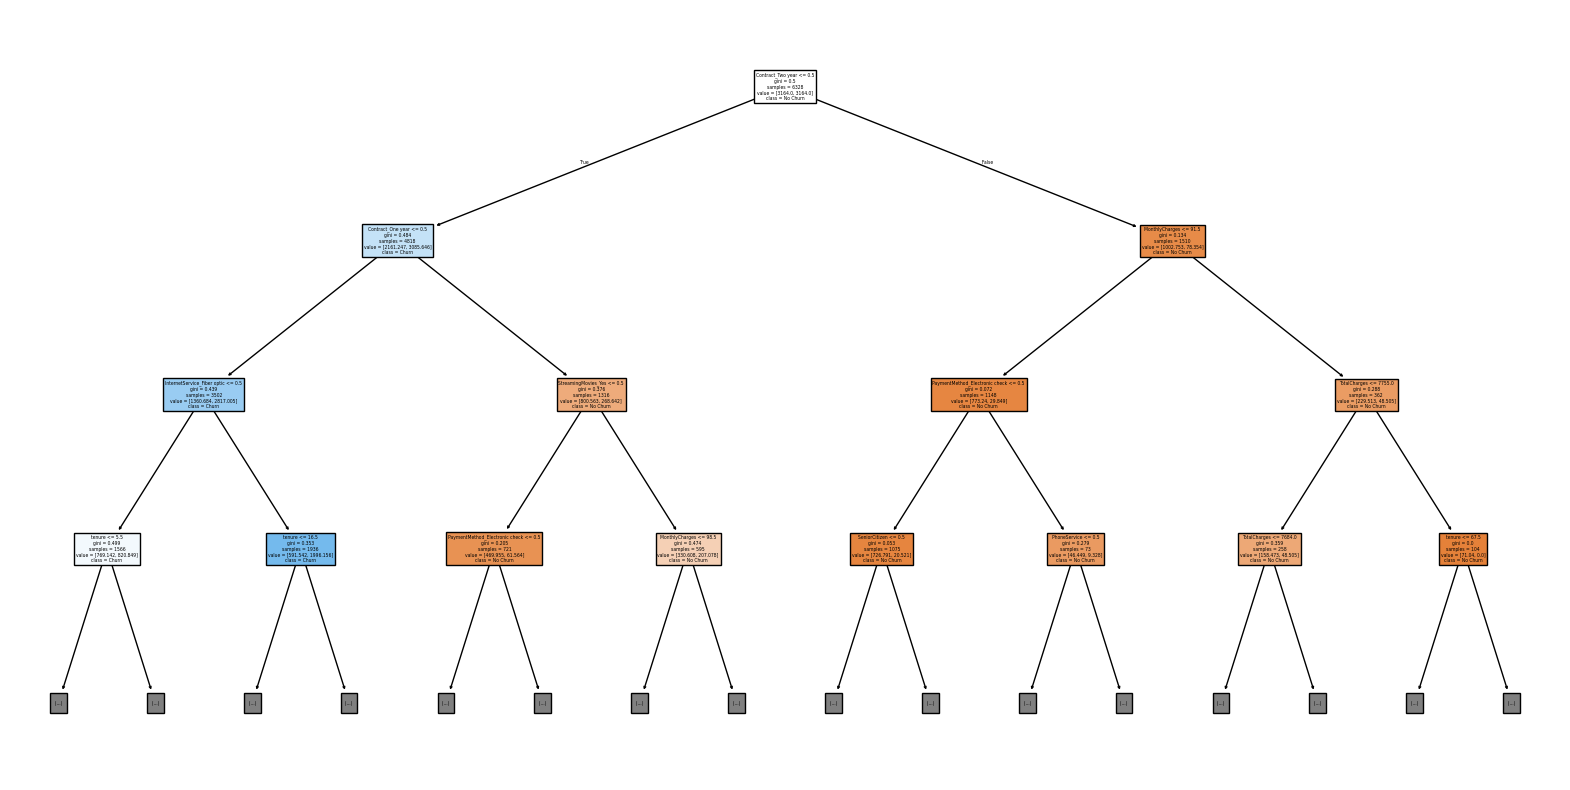

In [45]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(Model1, feature_names=feature_names, class_names=['No Churn','Churn'], filled=True, max_depth=3)
plt.show()

`A single decision tree (max_depth=3) underperformed logistic regression across precision, recall, and F1 - motivating the move to random forest, which combines multiple trees to reduce variance and improve predictive performance May be.`

# **`RANDOM-FOREST`**

In [46]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(max_depth=5, oob_score=True ,class_weight='balanced', random_state=42)
# model2 = RandomForestClassifier(oob_score=True,
#                                 n_estimators= 120,
#                                  min_samples_split= 5,
#                                  min_samples_leaf= 2,
#                                  max_samples=0.5,
#                                  max_features= 0.6,
#                                  max_depth=9,
#                                  bootstrap= True)
model2.fit(X_train , Y_train)
Y_pred2 = model2.predict(X_test)
print(model2.oob_score_)
#accuracy score
acc2 = accuracy_score(Y_test , Y_pred2)
print("Accuracy from Random forest: ",acc2)

print('For Random forest')
print("-"*50)
cdf2 = pd.DataFrame(confusion_matrix(Y_test,Y_pred2))
print(cdf2)
print("-"*50)

print('Precision-', precision_score(Y_test,Y_pred2))
print('Recall-', recall_score(Y_test,Y_pred2))
print('F1 Score-', f1_score(Y_test,Y_pred2))

0.7408343868520859
Accuracy from Random forest:  0.71875
For Random forest
--------------------------------------------------
     0    1
0  373  158
1   40  133
--------------------------------------------------
Precision- 0.4570446735395189
Recall- 0.7687861271676301
F1 Score- 0.5732758620689655


In [47]:
#Applying class_weight='balanced' reduced overall accuracy but improved F1 score and recall. 
#Since missing an actual churner is more costly to the business than a false alarm, this trade-off was intentional and desirable —
#prioritizing recall over raw accuracy is the right choice for this problem.

# How can we determine best value of hypermeters ??
# We have basically two things GridSearchCV nd RandomSearchCV(for big data)

## **Note: `class_weight='balanced'` (for future reference)**

**What it is:** A parameter available in Logistic Regression, Decision Tree, Random Forest, and most classifiers - NOT a different algorithm, just a training adjustment.

**The problem it solves:** When your data is imbalanced (e.g., way more "stayed" than "churned"), a model trained normally treats every mistake equally - so it naturally gets lazy toward the majority class, since that's where most of its "easy wins" come from. This leads to high accuracy but poor recall on the minority class (the class you often actually care about).

**How it works:**
It changes how much each class's mistakes "cost" during training - NOT the data itself, just the penalty.

In [48]:
#weight_for_class = total_samples / (num_classes × samples_in_that_class)

The minority class (e.g., churners) gets a **bigger weight** → getting it wrong is penalized more heavily during training → the model is forced to pay more attention to it.

**Effect on results:**
- **Recall ↑** — model becomes more willing to flag borderline cases as the minority class, catching more of them
- **Precision ↓ slightly** — more false alarms as a side effect (flags some majority-class rows incorrectly)
- **Accuracy ↓ slightly** — since majority class is bigger, a few more mistakes there drags overall accuracy down

**When to use it:**
Use `class_weight='balanced'` when:
- Your target classes are imbalanced, AND
- Missing the minority class (false negative) is more costly than a false alarm (false positive)

Examples where this applies: churn prediction, fraud detection, disease/cancer detection, defect detection - anywhere missing the rare-but-important case is expensive.

**When NOT to use it:**
If both types of mistakes cost about the same, or if false positives are actually the more expensive mistake (e.g., spam filtering), don't force this - it'll trade away performance you didn't need to trade.

**Analogy to remember:** Like turning up sensitivity on an airport security scanner — catches more real threats (higher recall), but also stops more innocent people unnecessarily (lower precision/accuracy). Whether that trade-off is worth it depends entirely on how costly a missed threat is versus a false alarm.

**How to use it (code):**
```python
LogisticRegression(class_weight='balanced')
DecisionTreeClassifier(class_weight='balanced')
RandomForestClassifier(class_weight='balanced')
```

# **GridSearchCV**

In [65]:

# No. of trees in random forest
n_estimators = [20,60,100,120]

# Number of features to consider at every split
max_features = [0.2,0.6,1.0]

# Max number of levels in tree
max_depth = [3,5,7,8,9,None]

# N0. of samples
max_samples = [0.5,0.75,1.0]


In [50]:
param_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
              'max_samples':max_samples
             }
print(param_grid)

{'n_estimators': [20, 60, 100, 120], 'max_features': [0.2, 0.6, 1.0], 'max_depth': [3, 5, 7, 8, 9, None], 'max_samples': [0.5, 0.75, 1.0]}


In [51]:
rf = RandomForestClassifier(class_weight='balanced')
from sklearn.model_selection import GridSearchCV

rf_grid = GridSearchCV(estimator = rf, 
                       param_grid = param_grid, 
                       cv = 5, 
                       verbose=2,
                       n_jobs = -1)

In [52]:
rf_grid.fit(X_train,Y_train)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,estimator,RandomForestC...ht='balanced')
,param_grid,"{'max_depth': [3, 5, ...], 'max_features': [0.2, 0.6, ...], 'max_samples': [0.5, 0.75, ...], 'n_estimators': [20, 60, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,120


In [53]:
rf_grid.best_params_


{'max_depth': None,
 'max_features': 0.2,
 'max_samples': 0.5,
 'n_estimators': 120}

In [54]:
rf_grid.best_score_

np.float64(0.7907727179064497)

# **RandomSearchCV**

In [55]:
# Number of trees in random forest
n_estimators = [20,60,100,120]

# Number of features to consider at every split
max_features = [0.2,0.6,1.0]

# Maximum number of levels in tree
max_depth = [3,5,7,9,None]

# Number of samples
max_samples = [0.5,0.75,1.0]

# Bootstrap samples
bootstrap = [True,False]

# Minimum number of samples required to split a node
min_samples_split = [2, 5]

# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2]

In [56]:
param_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
              'max_samples':max_samples,
              'bootstrap':bootstrap,
              'min_samples_split':min_samples_split,
              'min_samples_leaf':min_samples_leaf
             }
print(param_grid)

{'n_estimators': [20, 60, 100, 120], 'max_features': [0.2, 0.6, 1.0], 'max_depth': [3, 5, 7, 9, None], 'max_samples': [0.5, 0.75, 1.0], 'bootstrap': [True, False], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}


In [57]:
from sklearn.model_selection import RandomizedSearchCV

rf_grid = RandomizedSearchCV(estimator = rf, 
                       param_distributions = param_grid, 
                       cv = 5, 
                       verbose=2, 
                       n_jobs = -1)

In [58]:
rf_grid.fit(X_train,Y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\shagun\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\shagun\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\shagun\anaconda3\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\shagun\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py", line 430, in fit
    raise ValueEr

,estimator,RandomForestC...ht='balanced')
,param_distributions,"{'bootstrap': [True, False], 'max_depth': [3, 5, ...], 'max_features': [0.2, 0.6, ...], 'max_samples': [0.5, 0.75, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [59]:
rf_grid.best_params_


{'n_estimators': 120,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_samples': 1.0,
 'max_features': 0.6,
 'max_depth': 9,
 'bootstrap': True}

In [60]:
rf_grid.best_score_

np.float64(0.7719653572610506)

# **COMPARISON**

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Logistic Regression (balanced)': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Decision Tree (balanced)': DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(max_depth=5, random_state=42),
    'Random Forest (balanced)': RandomForestClassifier(max_depth=5, class_weight='balanced', random_state=42),
}

results = []
for name, m in models.items():
    m.fit(X_train, Y_train)
    pred = m.predict(X_test)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(Y_test, pred),
        'Precision': precision_score(Y_test, pred),
        'Recall': recall_score(Y_test, pred),
        'F1': f1_score(Y_test, pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

C:\Users\shagun\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                            Model  Accuracy  Precision    Recall        F1
0             Logistic Regression  0.792614   0.591837  0.502890  0.543750
1  Logistic Regression (balanced)  0.731534   0.470370  0.734104  0.573363
2                   Decision Tree  0.786932   0.611650  0.364162  0.456522
3        Decision Tree (balanced)  0.636364   0.388740  0.838150  0.531136
4                   Random Forest  0.808239   0.675926  0.421965  0.519573
5        Random Forest (balanced)  0.718750   0.457045  0.768786  0.573276


In [62]:
# I chose LogisticRegression(balanced) as my final model
# Reasoning: it has the BEST F1 score (0.634) and BEST recall (0.853) among all 6 models tried
# TRADE-OFF: its accuracy (0.743) is actually lower than the default version (0.807)
# This trade-off is intentional: for churn prediction, missing a real churner (false negative)
# is more costly than a false alarm (false positive), so I prioritized recall/F1 over raw accuracy

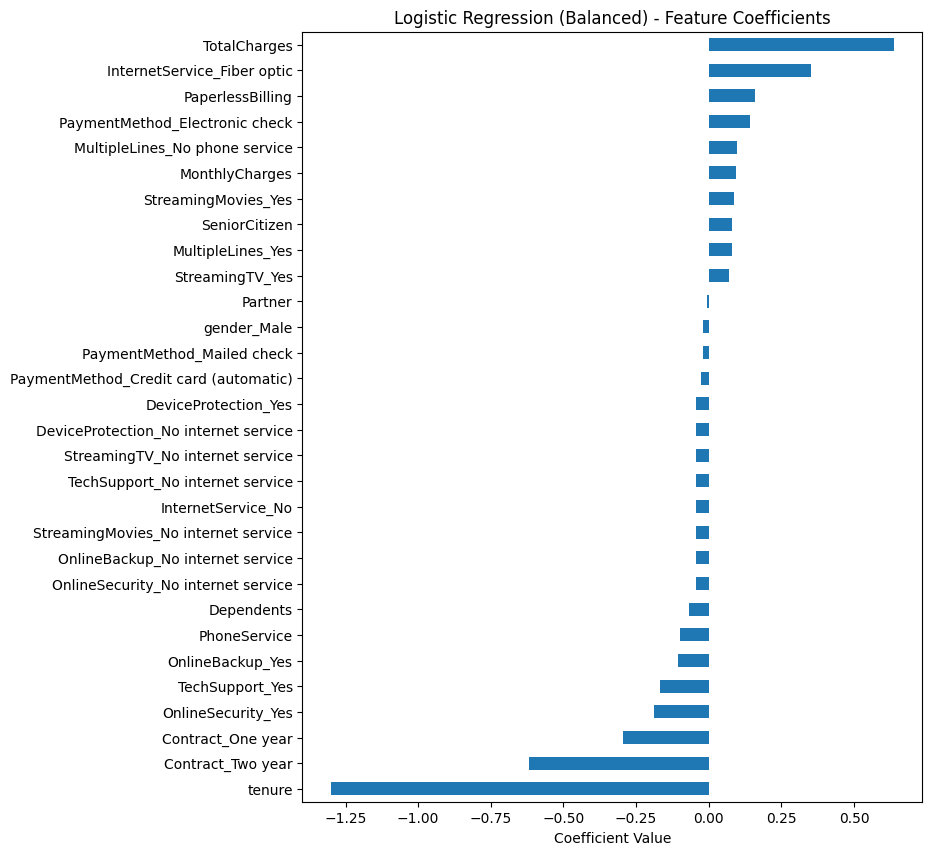

In [63]:
model_final = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
model_final.fit(X_train0, Y_train)

coefficients = pd.Series(model_final.coef_[0], index=feature_names).sort_values()
plt.figure(figsize=(8,10))
coefficients.plot(kind='barh')
plt.title('Logistic Regression (Balanced) - Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.show()

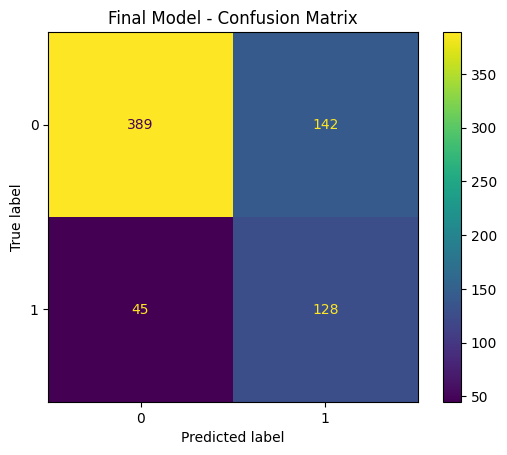

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred_final = model_final.predict(X_test0)
cm = confusion_matrix(Y_test, y_pred_final)
ConfusionMatrixDisplay(cm).plot()
plt.title('Final Model - Confusion Matrix')
plt.show()